# NB09bV3: Unsupervised Baselines + UISEM Ensemble v1 (V3 per-point sample unit)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|---|---|
| Notebook | `09bV3_Unsupervised_UISEM_v1.ipynb` |
| Version | `V3 v1` |
| Pipeline position | After NB05bV3 v6, parallel to NB09b v5. Consumes V3 (per-point) parquets. |

## NB09bV3 v1 vs NB09b v5

Same unsupervised baselines (PWTT, CCD, log-ratio) + Ahmad 2024 UISEM ensemble,
same cells B0-B8. The single change is the sample unit: V3 per-point single-pixel
parquets instead of V2 per-footprint parquets.

V3 is the correct architecture for NB09b because every replicated method operates
at per-pixel level:
- Aimaiti 2022 log-ratio: per-pixel log(post/pre) backscatter
- Ballinger 2024 PWTT: per-pixel Welch t-test
- Ahmad 2024 UISEM: per-pixel supervised ensemble
- Scher & Van Den Hoek 2025 CCD: per-pixel coherence change detection

### Changes from NB09b v5 (purely surgical)

- Sample-unit column: `'building_id'` -> `'point_id'`.
- Dataset path: `DATASET_ROOT_V2` -> `DATASET_ROOT_V3`.
- Sample-unit parquet: `bda_buildings` -> `bda_points`.
- `df_bldg` / `df_buildings` -> `df_points` (internal variable name).
- `load_v2(name)` -> `load_v3(name)` (helper function name).
- Output dir: `RESULTS_ROOT / 'nb09b'` -> `RESULTS_ROOT / 'nb09b_v3'`.
- Registry tag: `NB09b_v2` -> `NB09bV3_v1`.
- OOF schema: `building_id` column -> `point_id` column.
- Centroid references: `centroid_x`/`centroid_y` -> `x_utm`/`y_utm` fallback chain.

# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB09bV3 CONFIG + GLOBAL SETUP
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-29 23:01:40
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     909.9/7452.0 GB (6542.1 GB free)
  GDrive (F:)     1404.5/3726.0 GB (2321.5 GB free)
  Local data      11557.6/14901.9 GB (3344.3 GB free)
  Data stack      1404.5/3726.0 GB (2321.5 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: MANIFEST + BUILDINGS + SHARED HELPERSLoads V3 parquet manifest, building metadata, defines `load_v2(manifest_key)`.Every B-cell calls `load_v2(key)` then does `del df; gc.collect()`.No upfront load of product_prepost/scene_card/temporal_coh — each B-cell loadsonly what it needs.

In [2]:
# @title CELL S0: MANIFEST + BUILDINGS + SHARED HELPERS
import sys, importlib, re, time, gc, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, VotingClassifier, AdaBoostClassifier)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

from lightgbm import LGBMClassifier

print("=" * 70)
print("CELL S0: NB09bV3 v1 - MANIFEST + BUILDINGS + HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# --- load V3 manifest -------------------------------------------------
# V3 dataset path (not in global_setup.py which only defines V2)
DATASET_ROOT_V3 = STACK_DIR / 'dataset' / 'v3'
MANIFEST_V3_PATH = DATASET_ROOT_V3 / 'parquet_manifest.json'
if not MANIFEST_V3_PATH.exists():
    raise FileNotFoundError(f"V3 manifest not found: {MANIFEST_V3_PATH}")
with open(MANIFEST_V3_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V3_PATH}")
print(f"  Parquets: {len(MANIFEST['parquets'])}")

# --- load point metadata (V3 path) --------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V3 / 'bda_points_t{tier}.parquet')
df_points = load_tier_parquets(_bldg_pattern, _tiers)

CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
df_points = df_points[df_points['city'].isin(CITIES_TO_PROCESS)].copy()
df_points = df_points[df_points['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Points: {len(df_points)} (damaged={int((df_points['damage_binary']==1).sum())}, undamaged={int((df_points['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
N_FOLDS = 5
EXPERIMENT_LOG = {}
DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749, 'precision': 0.671, 'recall': 0.846}
BALLINGER_PAPER = {'auc': 0.87}

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
from scipy.stats import rankdata as _rankdata

# --- V3 column-name resolution -------------------------------------------
# V2 zonal aggregation appends _mean/_std/_max/_mode to every TIF-derived
# column. V3 single-pixel extraction does NOT — the column is just the TIF
# stem. This helper resolves V2-style column names to V3-style by stripping
# the trailing zonal suffix if the V2 name is not found in the DataFrame.
_ZONAL_SUFFIXES = ('_mean', '_std', '_max', '_mode')

def resolve_col(df, v2_name):
    if v2_name in df.columns:
        return v2_name
    for suf in _ZONAL_SUFFIXES:
        if v2_name.endswith(suf):
            bare = v2_name[:-len(suf)]
            if bare in df.columns:
                return bare
    return None

def resolve_cols_list(df, v2_names):
    return [resolve_col(df, n) for n in v2_names]

EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09b_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = (RESULTS_ROOT / 'nb09b_v3' / 'oof_predictions')
OOF_DIR.mkdir(parents=True, exist_ok=True)

def save_oof_from_result(res, model_id, variant_id='',
                         is_final=False, threshold=0.5):
    '''Supervised: canonical OOF from a result dict (y_true, y_proba, groups,
       building_id, fold_id all valid-masked same length).'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys")
        return None
    y_proba = np.asarray(res['y_proba'])
    yt = np.asarray(res['y_true']).astype(int)
    fold = np.asarray(res['fold_id']).astype(int)
    bid = np.asarray(res['point_id'])
    cty = np.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'point_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

def save_oof_unsupervised(building_ids, cities, y_true, scores, model_id,
                          variant_id='', threshold=0.5):
    '''Unsupervised: rank-normalize raw scores to [0,1] then threshold at median.
       fold_id=0 (single-pass evaluation). Above-median score -> predicted damaged.'''
    scores = np.asarray(scores, dtype=float)
    valid = ~np.isnan(scores)
    if valid.sum() == 0:
        print(f"    [save_oof_unsup] skipped {model_id}: no valid scores")
        return None
    s = scores[valid]
    yt = np.asarray(y_true).astype(int)[valid]
    bid = np.asarray(building_ids)[valid]
    cty = np.asarray(cities)[valid]
    y_proba = _rankdata(s) / len(s)
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'point_id':   bid,
        'city':          cty,
        'fold_id':       np.zeros(len(yt), dtype=int),
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      False,
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- metadata filter: single source of truth for leakage exclusion ----
# Previous hardcoded LEAKAGE_EXCLUDE_PATTERNS (4 patterns) covered only a
# subset of leakage vectors -- missing was_observed_*, s1__vv__scenes_observed,
# s2__scenes_observed, s2__lu__scenes_observed, s2__visibility__{fire,smoke,
# clear}__freq, block __count_*, rolling __count_*, and the full dietrich
# pixel-count family. metadata_filter.is_non_feature() catches all of them
# via pattern rules and a name-based metadata whitelist.
import importlib
import metadata_filter
importlib.reload(metadata_filter)
from metadata_filter import is_non_feature

def drop_leakage(cols):
    # Thin wrapper so existing prepare_features() and experiment cells keep
    # working. Strictly MORE restrictive than the old 4-pattern filter.
    return [c for c in cols if not is_non_feature(c)]


# --- v2 manifest-driven loader ---------------------------------------
def load_v3(manifest_key, tiers=None, columns=None, sample_frac=None):
    '''Load a v2 parquet by manifest key, merge with points, return df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V3 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"  WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'point_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_points[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v3('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df
# --- shared eval helpers (unchanged from v20) ------------------------
def prepare_Xy_from(src_df, feat_cols):
    '''Extract X, y, groups, building_ids from a given df. Drops all-NaN cols, median-impute.'''
    avail = [c for c in feat_cols if c in src_df.columns]
    avail = drop_leakage(avail)
    if len(avail) < 2:
        return None, None, None, None, None
    df_valid = src_df[src_df[TARGET_COL] >= 0].copy()
    row_mask = ~df_valid[avail].isna().all(axis=1)
    df_sub = df_valid[row_mask]
    nan_col = df_sub[avail].isna().all()
    clean = [c for c in avail if not nan_col[c]]
    if len(clean) < 2:
        return None, None, None, None, None
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(df_sub[clean].values)
    y = df_sub[TARGET_COL].values
    groups = df_sub['city'].values
    building_ids = df_sub['point_id'].values
    return X, y, groups, building_ids, clean


def evaluate_groupkfold(clf, X, y, groups, label="", n_folds=N_FOLDS, building_ids=None):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {label}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        clf_copy = clone(clf)
        clf_copy.fit(X[train_idx], y[train_idx])
        if hasattr(clf_copy, 'predict_proba'):
            y_proba_oof[test_idx] = clf_copy.predict_proba(X[test_idx])[:, 1]
        else:
            raw = clf_copy.decision_function(X[test_idx])
            y_proba_oof[test_idx] = 1.0 / (1.0 + np.exp(-raw))
        fold_id[test_idx] = fold_idx
        if len(np.unique(y[test_idx])) > 1:
            fold_aucs.append(roc_auc_score(y[test_idx], y_proba_oof[test_idx]))
    valid = ~np.isnan(y_proba_oof)
    auc = roc_auc_score(y[valid], y_proba_oof[valid])
    f1 = f1_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int))
    bid_v = (np.asarray(building_ids)[valid] if building_ids is not None
             else np.arange(len(y))[valid].astype(str))
    res = {'auc': auc, 'f1': f1, 'auc_std': np.std(fold_aucs), 'fold_aucs': fold_aucs,
           'y_true': y[valid], 'y_proba': y_proba_oof[valid], 'groups': groups[valid],
           'point_id': bid_v, 'fold_id': fold_id[valid],
           'n_features': X.shape[1], 'experiment': label}
    EXPERIMENT_LOG[label] = res
    print(f"    {label:45s}: AUC={auc:.3f} (+/-{np.std(fold_aucs):.3f})  F1={f1:.3f}")
    return res


def build_uisem(include_adaboost=True):
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                       n_jobs=-1, class_weight='balanced')),
        # Ahmad 2024 used sklearn GradientBoostingClassifier; swapped for LGBM
        # (same gradient-boosting family, histogram-based, ~50-100x faster on 600k rows).
        ('gb', LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                               num_leaves=31, random_state=RANDOM_STATE,
                               n_jobs=-1, verbose=-1)),
    ]
    if HAS_XGB:
        estimators.append(('xgb', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                  scale_pos_weight=5, eval_metric='logloss', verbosity=0)))
    if include_adaboost:
        estimators.append(('ab', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)))
    return VotingClassifier(estimators=estimators, voting='soft')


# --- registry + output ----------------------------------------------
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09bV3_v1')

def log_result(res, cell_id='', parquet_name='', feature_set_name='',
               classifier_name='', feature_cols=None, groups=None,
               cv_method='GroupKFold', note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id,
        experiment_name=res.get('experiment', ''),
        parquet_name=parquet_name,
        tier_selection=_tiers,
        classifier_name=classifier_name,
        feature_set_name=feature_set_name,
        feature_cols=feature_cols,
        cv_method=cv_method, n_folds=N_FOLDS, imputation='median',
        y_true=res.get('y_true'), y_proba=res.get('y_proba'),
        groups=res.get('groups', groups),
        note=note, tags=tags or [],
    )


import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_ROOT / 'nb09b_v3'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

# --- score collector for B4 (populated by B0/B1/B2/B3) ---------------
ALL_SCORES = {}   # label -> DataFrame with ['point_id', 'city', 'score_<label>']
B0_RESULTS = {}   # label -> dict (for B4 ladder consumption)


print(f"  Helpers: load_v3(), prepare_Xy_from(), evaluate_groupkfold(), build_uisem()")
print(f"  Output: {OUT_DIR}")

CELL S0: NB09bV3 v1 - MANIFEST + BUILDINGS + HELPERS
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v3/parquet_manifest.json
  Parquets: 36
  load_tier_parquets: 3 tiers, 63243 rows
  Cities: 21
  Points: 63243 (damaged=8247, undamaged=54996)
  EXPERIMENT_ID: 20260429_230318_6835ef
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260429_230318)
  Helpers: load_v3(), prepare_Xy_from(), evaluate_groupkfold(), build_uisem()
  Output: /content/drive_f/masterthesis/results/nb09b_v3


In [3]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_points to df_points for plotting helper compatibility
df_points = df_points

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_points
    # V3: use x_utm/y_utm as primary coordinates; fall back to centroid_x/y (V2)
    if 'x_utm' in bdf.columns and 'y_utm' in bdf.columns:
        _cx, _cy = 'x_utm', 'y_utm'
    elif 'centroid_x' in bdf.columns and 'centroid_y' in bdf.columns:
        _cx, _cy = 'centroid_x', 'centroid_y'
    else:
        print("  plot_cm_spatial: no coordinate columns (x_utm/centroid_x)")
        return None
    plot_df = oof.merge(bdf[['point_id', 'city', _cx, _cy]],
                        on=['point_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts[_cx], pts[_cy],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL B0: SINGLE-FEATURE CHANGE BASELINES (V3)For every pre/post pair in V3 atomics, compute pre-post change and AUC.Loads THREE parquets sequentially, del+gc between each: - `block_stats` A15 (CARD baseline + blk01) - `coh_drop` A14 (COH drops) - `composite_prepost_bands` A9 (MS pre/post bands)Results accumulated into `ALL_SCORES` for B4 ladder.

CELL B0: SINGLE-FEATURE CHANGE BASELINES

  --- CARD pairs (block_stats A15: baseline vs blk01) ---
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities
  CARD pairs found: 2
  s1_vv_mean                               n=  63243  drop=0.488  -chg=0.488  |chg|=0.518  best=0.518 (|change|)
  REG: B0_single_s1_vv_mean                          AUC=0.5184 F1=0.2220 n=63243 feat=2 cities=21 [NB09bV3_v1/cell_b0]
    saved oof -> oof_B0_single_s1_vv_mean__20260429_230318_6835ef.parquet  TP=4309 FN=3938 FP=27313 TN=27683
  s1_vh_mean                               n=  63243  drop=0.506  -chg=0.506  |chg|=0.523  best=0.523 (|change|)
  REG: B0_single_s1_vh_mean                          AUC=0.5230 F1=0.2249 n=63243 feat=2 cities=21 [NB09bV3_v1/cell_b0]
    saved oof -> oof_B0_single_s1_vh_mean__20260429_230318_6835ef.parquet  TP=4310 FN=3937 FP=27312 TN=27684

  --- COH drop stats (coh_drop A14, single-feature) ---
  load_v3('coh_drop'): 51,800 rows, 11 cols, 12 cities
  COH drop score column

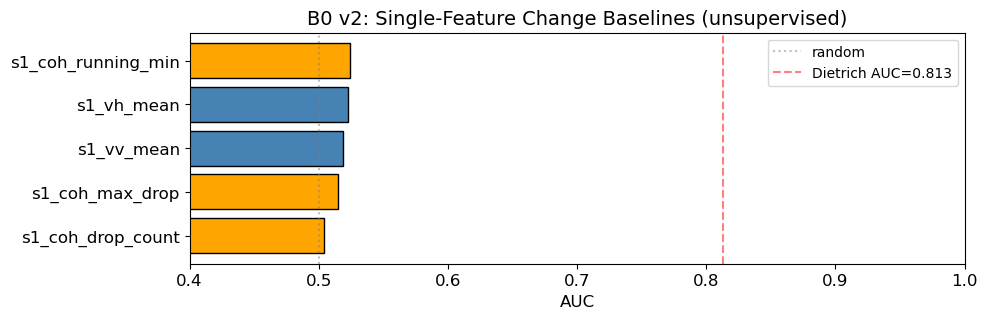

  Plot: cell_b0/single_feature_baselines_20260429_230324.png


In [4]:
# @title CELL B0: SINGLE-FEATURE CHANGE BASELINES (V3)
print("=" * 70)
print("CELL B0: SINGLE-FEATURE CHANGE BASELINES")
print("=" * 70)

def evaluate_change_pair(sub, label, bl_col, as_col, source_parquet):
    '''Score one pre/post pair three ways, pick best, log and save into ALL_SCORES.'''
    if len(sub) < 50 or sub[TARGET_COL].nunique() < 2:
        print(f"  {label:<40s} SKIP ({len(sub)} rows)")
        return
    y = sub[TARGET_COL].values
    change = sub[as_col].values - sub[bl_col].values
    drop = sub[bl_col].values - sub[as_col].values

    auc_drop = roc_auc_score(y, drop)
    auc_neg = roc_auc_score(y, -change)
    auc_abs = roc_auc_score(y, np.abs(change))
    auc_best = max(auc_drop, auc_neg, auc_abs)
    if auc_best == auc_drop:
        direction, best_scores = 'drop', drop
    elif auc_best == auc_neg:
        direction, best_scores = '-change', -change
    else:
        direction, best_scores = '|change|', np.abs(change)

    print(f"  {label:<40s} n={len(sub):>7d}  drop={auc_drop:.3f}  -chg={auc_neg:.3f}  |chg|={auc_abs:.3f}  best={auc_best:.3f} ({direction})")

    exp_name = f'B0_single_{label}'
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1,
                                 'method': 'unsupervised', 'direction': direction}
    B0_RESULTS[label] = {'auc': auc_best, 'direction': direction, 'n': len(sub),
                          'bl_col': bl_col, 'as_col': as_col, 'scores': best_scores,
                          'building_ids': sub['point_id'].values,
                          'cities': sub['city'].values, 'y': y}
    ALL_SCORES[label] = pd.DataFrame({
        'point_id': sub['point_id'].values,
        'city': sub['city'].values,
        f'score_{label}': best_scores,
    })

    registry.log_experiment(
        cell_id='cell_b0', experiment_name=exp_name,
        parquet_name=source_parquet, tier_selection=_tiers,
        classifier_name='unsupervised_change',
        feature_set_name=label, feature_cols=[bl_col, as_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores, groups=sub['city'].values,
        note=f'Single-feature pre/post change: {label}, direction={direction}',
        tags=['unsupervised', 'single_feature', label],
    )
    save_oof_unsupervised(
        building_ids=sub['point_id'].values, cities=sub['city'].values,
        y_true=y, scores=best_scores, model_id=exp_name,
        variant_id=f'unsupervised_change;source={source_parquet};direction={direction}',
    )


# --- Step 1: CARD baseline vs blk01 from block_stats A15 -------------
print("\n  --- CARD pairs (block_stats A15: baseline vs blk01) ---")
df_blk = load_v3('block_stats')

# match baseline/blk01 mean-zonal pairs for VV/VH (exclude count)
card_pairs = []
for pol in ('vv', 'vh'):
    bl_cols = [c for c in df_blk.columns
               if c.startswith(f's1__{pol}__baseline__') and c.endswith('_mean')
               and c.split('__')[3].split('_')[0] != 'count']
    for bl in bl_cols:
        asc = bl.replace('__baseline__', '__blk01__')
        if asc in df_blk.columns:
            # label: e.g. s1_vv_baseline_mean_mean -> s1_vv_mean
            stat = bl.split('__')[3].split('_')[0]
            label = f's1_{pol}_{stat}'
            card_pairs.append((label, bl, asc))
print(f"  CARD pairs found: {len(card_pairs)}")

for label, bl, asc in card_pairs:
    sub = df_blk[['point_id', 'city', TARGET_COL, bl, asc]].dropna()
    evaluate_change_pair(sub, label, bl, asc, 'bda_block_stats_v3')

del df_blk
gc.collect()


# --- Step 2: COH from coh_drop A14 -----------------------------------
# A14 stores already-derived drop statistics (no pre/post pair structure).
# Each column is a single-feature damage score directly.
print("\n  --- COH drop stats (coh_drop A14, single-feature) ---")
df_coh = load_v3('coh_drop')

def evaluate_single_score(sub, label, score_col, source_parquet, higher_is_damage=True):
    if len(sub) < 50 or sub[TARGET_COL].nunique() < 2:
        print(f"  {label:<40s} SKIP ({len(sub)} rows)")
        return
    y = sub[TARGET_COL].values
    raw = sub[score_col].values
    auc_pos = roc_auc_score(y, raw)
    auc_neg = roc_auc_score(y, -raw)
    auc_abs = roc_auc_score(y, np.abs(raw))
    auc_best = max(auc_pos, auc_neg, auc_abs)
    if auc_best == auc_pos:
        direction, best_scores = '+raw', raw
    elif auc_best == auc_neg:
        direction, best_scores = '-raw', -raw
    else:
        direction, best_scores = '|raw|', np.abs(raw)
    print(f"  {label:<40s} n={len(sub):>7d}  +raw={auc_pos:.3f}  -raw={auc_neg:.3f}  |raw|={auc_abs:.3f}  best={auc_best:.3f} ({direction})")
    exp_name = f'B0_single_{label}'
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1,
                                 'method': 'unsupervised', 'direction': direction}
    B0_RESULTS[label] = {'auc': auc_best, 'direction': direction, 'n': len(sub),
                          'bl_col': score_col, 'as_col': None, 'scores': best_scores,
                          'building_ids': sub['point_id'].values,
                          'cities': sub['city'].values, 'y': y}
    ALL_SCORES[label] = pd.DataFrame({
        'point_id': sub['point_id'].values,
        'city': sub['city'].values,
        f'score_{label}': best_scores,
    })
    registry.log_experiment(
        cell_id='cell_b0', experiment_name=exp_name,
        parquet_name=source_parquet, tier_selection=_tiers,
        classifier_name='unsupervised_single_score',
        feature_set_name=label, feature_cols=[score_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores, groups=sub['city'].values,
        note=f'Single-score: {label}, direction={direction}',
        tags=['unsupervised', 'single_feature', label],
    )
    save_oof_unsupervised(
        building_ids=sub['point_id'].values, cities=sub['city'].values,
        y_true=y, scores=best_scores, model_id=exp_name,
        variant_id=f'unsupervised_single_score;source={source_parquet};direction={direction}',
    )

# A14 derived-drop damage signatures (skip leakage cols: scenes_observed)
coh_score_cols_v2 = [
    's1__coh__max_drop_mean',
    's1__coh__running_min_mean',
    's1__coh__drop_count_mean',
    's1__coh__max_drop_max',
    's1__coh__running_min_max',
]
# V3: resolve column names (strip zonal _mean/_max suffix if not found)
coh_score_cols = [resolve_col(df_coh, c) for c in coh_score_cols_v2]
coh_score_cols = [c for c in coh_score_cols if c is not None and c in df_coh.columns]
print(f"  COH drop score columns available: {len(coh_score_cols)}")

for col in coh_score_cols:
    label = 's1_coh_' + col.replace('s1__coh__', '').replace('_mean', 'M').replace('_max', 'X')
    sub = df_coh[['point_id', 'city', TARGET_COL, col]].dropna()
    evaluate_single_score(sub, label, col, 'bda_coh_drop_v3')

del df_coh
gc.collect()


# --- Step 3: MS from composite_prepost_bands A9 ----------------------
print("\n  --- MS pairs (composite_prepost_bands A9) ---")
df_ms = load_v3('composite_prepost_bands')

ms_info = MANIFEST['parquets']['composite_prepost_bands']
ms_feats = [c for c in ms_info['feature_columns'] if c in df_ms.columns]
# find pre/post pairs by string replacement (period tokens vary)
ms_pairs = []
for c in ms_feats:
    for pre_tok in ('__prebattle__', '__pre_', 'pre__', '_pre_'):
        if pre_tok in c:
            for post_tok in ('__postbattle__', '__post_winter__', '__post_', 'post__', '_post_'):
                cand = c.replace(pre_tok, post_tok, 1)
                if cand in ms_feats and cand != c:
                    label = c.replace(pre_tok, '_').replace('__', '_')
                    ms_pairs.append((label, c, cand))
                    break
            break
# dedupe by (bl, as)
seen = set()
ms_pairs_dedup = []
for label, bl, asc in ms_pairs:
    key = (bl, asc)
    if key in seen:
        continue
    seen.add(key)
    ms_pairs_dedup.append((label, bl, asc))
print(f"  MS pairs found: {len(ms_pairs_dedup)} (after dedup)")

for label, bl, asc in ms_pairs_dedup[:30]:  # cap to avoid console spam
    sub = df_ms[['point_id', 'city', TARGET_COL, bl, asc]].dropna()
    evaluate_change_pair(sub, label, bl, asc, 'bda_composite_prepost_bands_v3')

del df_ms
gc.collect()


# --- ranking + plot --------------------------------------------------
if B0_RESULTS:
    print(f"\n  Ranking (best to worst):")
    for rank, (label, r) in enumerate(sorted(B0_RESULTS.items(), key=lambda x: -x[1]['auc']), 1):
        print(f"    {rank:2d}. {label:<40s} AUC={r['auc']:.3f}  ({r['direction']}, n={r['n']})")

    labels_sorted = sorted(B0_RESULTS.keys(), key=lambda k: B0_RESULTS[k]['auc'])
    aucs = [B0_RESULTS[k]['auc'] for k in labels_sorted]
    colors = []
    for k in labels_sorted:
        if k.startswith('s1_coh'):
            colors.append('orange')
        elif k.startswith('s1_'):
            colors.append('steelblue')
        else:
            colors.append('green')
    fig, ax = plt.subplots(figsize=(10, max(3, len(labels_sorted) * 0.28)))
    ax.barh(labels_sorted, aucs, color=colors, edgecolor='black')
    ax.set_xlabel('AUC')
    ax.set_xlim(0.4, 1.0)
    ax.set_title('B0 v2: Single-Feature Change Baselines (unsupervised)')
    ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='random')
    ax.axvline(DIETRICH_PAPER['auc'], color='red', linestyle='--', alpha=0.5,
               label=f"Dietrich AUC={DIETRICH_PAPER['auc']}")
    ax.legend()
    save_fig(fig, 'single_feature_baselines', 'cell_b0')

# CELL B1: PWTT (Ballinger 2024, unsupervised)Welch t-test pre vs post backscatter per building.Exact mode: `scene_card` A2 (long, per-date) with `period_label` if present.Approx fallback: `prepost_single_card` A13 mean+std (no per-scene needed).Tests VV and VH. Output: |t| per building = damage score.

In [5]:
# @title CELL B1: PWTT (Ballinger 2024)
from scipy.stats import t as t_dist

print("=" * 70)
print("CELL B1: PWTT (Pixel-Wise T-Test)")
print("=" * 70)

def vectorized_welch_ttest(scene_df, val_col, pol_label):
    tmp = scene_df[['city', 'point_id', 'period_label', val_col]].copy()
    tmp = tmp.dropna(subset=[val_col])
    tmp['period_group'] = 'drop'
    tmp.loc[tmp['period_label'] == 'prebattle', 'period_group'] = 'pre'
    tmp.loc[tmp['period_label'].isin(['crossbattle', 'postbattle']), 'period_group'] = 'post'
    tmp = tmp[tmp['period_group'] != 'drop']
    agg = tmp.groupby(['city', 'point_id', 'period_group'])[val_col].agg(
        ['mean', 'std', 'count']).reset_index()
    pre = agg[agg['period_group'] == 'pre'].set_index(['city', 'point_id'])
    post = agg[agg['period_group'] == 'post'].set_index(['city', 'point_id'])
    joined = pre.join(post, lsuffix='_pre', rsuffix='_post', how='inner')
    joined = joined[(joined['count_pre'] >= 2) & (joined['count_post'] >= 2)]
    if len(joined) == 0:
        return None
    var_pre = joined['std_pre'] ** 2
    var_post = joined['std_post'] ** 2
    n_pre = joined['count_pre']
    n_post = joined['count_post']
    denom = np.sqrt(var_pre / n_pre + var_post / n_post + 1e-30)
    joined[f'pwtt_t_{pol_label}'] = (joined['mean_post'] - joined['mean_pre']) / denom
    return joined[[f'pwtt_t_{pol_label}']].reset_index()


def eval_pwtt(scores_df, t_col, exp_name, pol_label, source_parquet):
    if scores_df is None or len(scores_df) < 50:
        print(f"  {exp_name}: insufficient data")
        return None
    y = scores_df[TARGET_COL].values
    if len(np.unique(y)) < 2:
        print(f"  {exp_name}: only one class")
        return None
    scores_abs = np.abs(scores_df[t_col].values)
    scores_neg = -scores_df[t_col].values
    auc_abs = roc_auc_score(y, scores_abs)
    auc_neg = roc_auc_score(y, scores_neg)
    auc_best = max(auc_abs, auc_neg)
    direction = "|t|" if auc_abs >= auc_neg else "-t"
    best_scores = scores_abs if auc_abs >= auc_neg else scores_neg
    print(f"  {exp_name:<30s} ({pol_label}): AUC(|t|)={auc_abs:.3f}  AUC(-t)={auc_neg:.3f}  best={auc_best:.3f} ({direction})")
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1,
                                 'method': 'unsupervised', 'direction': direction}
    ALL_SCORES[f'pwtt_{pol_label}'] = pd.DataFrame({
        'point_id': scores_df['point_id'].values,
        'city': scores_df['city'].values,
        f'score_pwtt_{pol_label}': best_scores,
    })
    registry.log_experiment(
        cell_id='cell_b1', experiment_name=exp_name,
        parquet_name=source_parquet, tier_selection=_tiers,
        classifier_name='unsupervised_ttest',
        feature_set_name=f'pwtt_{pol_label}', feature_cols=[t_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores, groups=scores_df['city'].values,
        note=f'Ballinger 2024 PWTT {pol_label}, paper AUC={BALLINGER_PAPER["auc"]}',
        tags=['unsupervised', 'pwtt', 'ballinger', pol_label],
    )
    save_oof_unsupervised(
        building_ids=scores_df['point_id'].values,
        cities=scores_df['city'].values,
        y_true=y, scores=best_scores, model_id=exp_name,
        variant_id=f'unsupervised_pwtt;pol={pol_label};direction={direction}',
    )
    return auc_best


# --- try EXACT mode: scene_card A2 -----------------------------------
pwtt_vv_scores = None
pwtt_vh_scores = None
exact_mode_used = False

try:
    df_sc = load_v3('scene_card')
    if 'period_label' in df_sc.columns:
        print("  Mode: EXACT (per-date scene_card A2)")
        exact_mode_used = True
        for pol in ('vv', 'vh'):
            vcol_cands = [c for c in df_sc.columns if f's1__{pol}' in c and 'mean' in c]
            if not vcol_cands:
                # V3: single-pixel columns have no _mean suffix
                vcol_cands = [c for c in df_sc.columns if c == f's1__{pol}']
            if not vcol_cands:
                continue
            vcol = vcol_cands[0]
            print(f"    {pol}: column={vcol}")
            res_ttest = vectorized_welch_ttest(df_sc, vcol, pol)
            if res_ttest is None:
                print(f"    {pol}: no buildings with >=2 pre AND >=2 post")
                continue
            merged = res_ttest.merge(df_points[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                                      on=['point_id', 'city'], how='inner')
            if pol == 'vv':
                pwtt_vv_scores = merged
                eval_pwtt(merged, 'pwtt_t_vv', 'B1_PWTT_VV_exact', 'vv', 'bda_scene_card_v3')
            else:
                pwtt_vh_scores = merged
                eval_pwtt(merged, 'pwtt_t_vh', 'B1_PWTT_VH_exact', 'vh', 'bda_scene_card_v3')
    else:
        print("  scene_card has no 'period_label' column — falling back to approx")
    del df_sc
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"  scene_card not available ({e}) — using approx fallback")


# --- APPROX fallback: prepost_single_card A13 -----------------------
if not exact_mode_used:
    print("\n  Mode: APPROXIMATE (prepost_single_card A13)")
    df_pp = load_v3('prepost_single_card')

    for pol in ('vv', 'vh'):
        pre_mean = resolve_col(df_pp, f'pre_{pol}_mean') or f'pre_{pol}_mean'
        post_mean = resolve_col(df_pp, f'post_{pol}_mean') or f'post_{pol}_mean'
        pre_std = resolve_col(df_pp, f'pre_{pol}_std')
        post_std = resolve_col(df_pp, f'post_{pol}_std')
        if pre_std is None or post_std is None:
            # V3 single-pixel: no within-point std. Use simple difference instead of t-stat.
            if pre_mean in df_pp.columns and post_mean in df_pp.columns:
                sub = df_pp[['point_id', 'city', TARGET_COL, pre_mean, post_mean]].dropna()
                t_approx = sub[post_mean] - sub[pre_mean]
                sub = sub.copy()
                sub[f'pwtt_t_{pol}'] = t_approx
                print(f"    {pol}: {len(sub)} points (V3 simple difference, no std available)")
                if pol == 'vv':
                    pwtt_vv_scores = sub[['point_id', 'city', TARGET_COL, 'pwtt_t_vv']].copy()
                    eval_pwtt(pwtt_vv_scores, 'pwtt_t_vv', 'B1_PWTT_VV_approx', 'vv', 'bda_prepost_single_card_v3')
                else:
                    eval_pwtt(sub, 'pwtt_t_vh', 'B1_PWTT_VH_approx', 'vh', 'bda_prepost_single_card_v3')
            else:
                print(f"    {pol}: missing pre/post columns, skip")
            continue
        if not all(c in df_pp.columns for c in (pre_mean, post_mean, pre_std, post_std)):
            print(f"    {pol}: missing columns, skip")
            continue
        sub = df_pp[['point_id', 'city', TARGET_COL, pre_mean, post_mean, pre_std, post_std]].dropna()
        t_approx = (sub[post_mean] - sub[pre_mean]) / np.sqrt(sub[pre_std]**2 + sub[post_std]**2 + 1e-10)
        sub = sub.copy()
        sub[f'pwtt_t_{pol}'] = t_approx
        print(f"    {pol}: {len(sub)} buildings (approx single-scene)")
        if pol == 'vv':
            pwtt_vv_scores = sub[['point_id', 'city', TARGET_COL, 'pwtt_t_vv']].copy()
            eval_pwtt(pwtt_vv_scores, 'pwtt_t_vv', 'B1_PWTT_VV_approx', 'vv',
                      'bda_prepost_single_card_v3')
        else:
            pwtt_vh_scores = sub[['point_id', 'city', TARGET_COL, 'pwtt_t_vh']].copy()
            eval_pwtt(pwtt_vh_scores, 'pwtt_t_vh', 'B1_PWTT_VH_approx', 'vh',
                      'bda_prepost_single_card_v3')

    del df_pp
    gc.collect()


# --- VV+VH combined -------------------------------------------------
if pwtt_vv_scores is not None and pwtt_vh_scores is not None:
    merged = pwtt_vv_scores[['point_id', 'city', TARGET_COL, 'pwtt_t_vv']].merge(
        pwtt_vh_scores[['point_id', 'city', 'pwtt_t_vh']],
        on=['point_id', 'city'], how='inner')
    if len(merged) > 50:
        combined_t = np.abs(merged['pwtt_t_vv'].values) + np.abs(merged['pwtt_t_vh'].values)
        y = merged[TARGET_COL].values
        if len(np.unique(y)) >= 2:
            auc_comb = roc_auc_score(y, combined_t)
            print(f"\n  PWTT VV+VH combined: AUC={auc_comb:.3f} ({len(merged)} buildings)")
            EXPERIMENT_LOG['B1_PWTT_VV+VH'] = {'auc': auc_comb, 'f1': np.nan,
                                                 'n_features': 2, 'method': 'unsupervised'}
            registry.log_experiment(
                cell_id='cell_b1', experiment_name='B1_PWTT_VV+VH',
                parquet_name='scene_card_v3' if exact_mode_used else 'prepost_single_card_v3',
                tier_selection=_tiers, classifier_name='unsupervised_ttest',
                feature_set_name='pwtt_vv+vh', feature_cols=['pwtt_t_vv', 'pwtt_t_vh'],
                cv_method='unsupervised', n_folds=0, imputation='none',
                y_true=y, y_proba=combined_t, groups=merged['city'].values,
                note='Ballinger 2024 PWTT VV+VH combined',
                tags=['unsupervised', 'pwtt', 'ballinger', 'combined'],
            )
            save_oof_unsupervised(
                building_ids=merged['point_id'].values,
                cities=merged['city'].values,
                y_true=y, scores=combined_t, model_id='B1_PWTT_VV+VH',
                variant_id='unsupervised_pwtt;pol=vv+vh',
            )

print(f"\n  Ballinger reference: AUC={BALLINGER_PAPER['auc']}")

CELL B1: PWTT (Pixel-Wise T-Test)
  load_v3('scene_card'): 834,134 rows, 8 cols, 21 cities
  Mode: EXACT (per-date scene_card A2)
    vv: column=s1__vv
  B1_PWTT_VV_exact               (vv): AUC(|t|)=0.526  AUC(-t)=0.485  best=0.526 (|t|)
  REG: B1_PWTT_VV_exact                              AUC=0.5260 F1=0.2245 n=62151 feat=1 cities=20 [NB09bV3_v1/cell_b1]
    saved oof -> oof_B1_PWTT_VV_exact__20260429_230318_6835ef.parquet  TP=4243 FN=3770 FP=26833 TN=27305
    vh: column=s1__vh
  B1_PWTT_VH_exact               (vh): AUC(|t|)=0.531  AUC(-t)=0.512  best=0.531 (|t|)
  REG: B1_PWTT_VH_exact                              AUC=0.5312 F1=0.2269 n=62151 feat=1 cities=20 [NB09bV3_v1/cell_b1]
    saved oof -> oof_B1_PWTT_VH_exact__20260429_230318_6835ef.parquet  TP=4317 FN=3696 FP=26759 TN=27379

  PWTT VV+VH combined: AUC=0.539 (62151 buildings)
  REG: B1_PWTT_VV+VH                                 AUC=0.5385 F1=0.2287 n=62151 feat=2 cities=20 [NB09bV3_v1/cell_b1]
    saved oof -> oof_B1_PWTT_V

# CELL B2: CCD (Coherence Change Detection)Pre-battle COH vs post-battle COH. COH drop = damage.Exact: `scene_coh` A3 (long per-date with `period_label` if present).Approx: `coh_drop` A14 (pre/post COH mean per building).

In [6]:
# @title CELL B2: CCD (Coherence Change Detection)
print("=" * 70)
print("CELL B2: CCD (Coherence Change Detection)")
print("=" * 70)

ccd_exact_done = False

# --- try EXACT mode: scene_coh A3 -----------------------------------
try:
    df_sc = load_v3('scene_coh')
    if 'period_label' in df_sc.columns:
        print("  Mode: EXACT (per-date scene_coh A3)")
        ccd_exact_done = True
        coh_val_cols = [c for c in df_sc.columns if 'coh' in c.lower() and 'mean' in c.lower()]
        for coh_col in coh_val_cols[:2]:
            pol = 'vv' if 'vv' in coh_col.lower() else 'vh' if 'vh' in coh_col.lower() else 'coh'
            print(f"    {coh_col} ({pol})")
            tmp = df_sc[['city', 'point_id', 'period_label', coh_col]].dropna(subset=[coh_col]).copy()
            tmp['period_group'] = 'drop'
            tmp.loc[tmp['period_label'] == 'prebattle', 'period_group'] = 'pre'
            tmp.loc[tmp['period_label'].isin(['crossbattle', 'postbattle']), 'period_group'] = 'post'
            tmp = tmp[tmp['period_group'] != 'drop']
            agg = tmp.groupby(['city', 'point_id', 'period_group'])[coh_col].mean().unstack('period_group')
            if 'pre' not in agg.columns or 'post' not in agg.columns:
                continue
            agg = agg.dropna(subset=['pre', 'post'])
            agg['ccd_score'] = agg['pre'] - agg['post']
            ccd_df = agg[['ccd_score']].reset_index()
            ccd_df = ccd_df.merge(df_points[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                                    on=['point_id', 'city'], how='inner')
            if len(ccd_df) > 50 and ccd_df[TARGET_COL].nunique() >= 2:
                y = ccd_df[TARGET_COL].values
                auc = roc_auc_score(y, ccd_df['ccd_score'].values)
                exp_name = f'B2_CCD_exact_{pol}'
                print(f"      AUC(drop)={auc:.3f}  ({len(ccd_df)} buildings)")
                EXPERIMENT_LOG[exp_name] = {'auc': auc, 'f1': np.nan,
                                             'n_features': 1, 'method': 'unsupervised'}
                ALL_SCORES[f'ccd_{pol}'] = pd.DataFrame({
                    'point_id': ccd_df['point_id'].values,
                    'city': ccd_df['city'].values,
                    f'score_ccd_{pol}': ccd_df['ccd_score'].values,
                })
                registry.log_experiment(
                    cell_id='cell_b2', experiment_name=exp_name,
                    parquet_name='bda_scene_coh_v3', tier_selection=_tiers,
                    classifier_name='unsupervised_ccd',
                    feature_set_name=f'coh_change_{pol}', feature_cols=[coh_col],
                    cv_method='unsupervised', n_folds=0, imputation='none',
                    y_true=y, y_proba=ccd_df['ccd_score'].values,
                    groups=ccd_df['city'].values,
                    note=f'CCD exact per-date {pol}',
                    tags=['unsupervised', 'ccd', 'coherence', 'exact', pol],
                )
                save_oof_unsupervised(
                    building_ids=ccd_df['point_id'].values,
                    cities=ccd_df['city'].values,
                    y_true=y, scores=ccd_df['ccd_score'].values,
                    model_id=exp_name,
                    variant_id=f'unsupervised_ccd;mode=exact;pol={pol}',
                )
    else:
        print("  scene_coh has no 'period_label' — falling back to approx")
    del df_sc
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"  scene_coh not available ({e}) — using approx fallback")


# --- APPROX fallback: coh_drop A14 ----------------------------------
# A14 stores already-derived drop statistics. Each column is a damage score.
if not ccd_exact_done:
    print("\n  Mode: APPROXIMATE (coh_drop A14 - derived drop stats)")
    df_coh = load_v3('coh_drop')

    # score candidates (higher drop = more damage). Skip leakage col scenes_observed.
    candidate_cols = [
        # V3: resolve column names (strip zonal suffix if not found)
        ('max_drop', resolve_col(df_cd, 's1__coh__max_drop_mean') or 's1__coh__max_drop'),
        ('running_min', resolve_col(df_cd, 's1__coh__running_min_mean') or 's1__coh__running_min'),
        ('drop_count', resolve_col(df_cd, 's1__coh__drop_count_mean') or 's1__coh__drop_count'),
    ]
    for label_suffix, col in candidate_cols:
        if col not in df_coh.columns:
            print(f"    {col}: not in A14")
            continue
        sub = df_coh[['point_id', 'city', TARGET_COL, col]].dropna()
        if len(sub) < 10 or sub[TARGET_COL].nunique() < 2:
            print(f"    {col}: insufficient data ({len(sub)} rows)")
            continue
        y = sub[TARGET_COL].values
        raw = sub[col].values
        auc_pos = roc_auc_score(y, raw)
        auc_neg = roc_auc_score(y, -raw)
        auc_best = max(auc_pos, auc_neg)
        direction = '+raw' if auc_pos >= auc_neg else '-raw'
        best_scores = raw if auc_pos >= auc_neg else -raw
        print(f"    {label_suffix} ({len(sub)} b): +raw={auc_pos:.3f}  -raw={auc_neg:.3f}  best={auc_best:.3f} ({direction})")
        exp_name = f'B2_CCD_approx_{label_suffix}'
        EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan,
                                     'n_features': 1, 'method': 'unsupervised'}
        ALL_SCORES[f'ccd_{label_suffix}'] = pd.DataFrame({
            'point_id': sub['point_id'].values,
            'city': sub['city'].values,
            f'score_ccd_{label_suffix}': best_scores,
        })
        registry.log_experiment(
            cell_id='cell_b2', experiment_name=exp_name,
            parquet_name='bda_coh_drop_v3', tier_selection=_tiers,
            classifier_name='unsupervised_ccd',
            feature_set_name=f'coh_{label_suffix}', feature_cols=[col],
            cv_method='unsupervised', n_folds=0, imputation='none',
            y_true=y, y_proba=best_scores, groups=sub['city'].values,
            note=f'CCD approximate from A14 derived drop stat: {col}',
            tags=['unsupervised', 'ccd', 'coherence', 'approx', label_suffix],
        )
        save_oof_unsupervised(
            building_ids=sub['point_id'].values, cities=sub['city'].values,
            y_true=y, scores=best_scores, model_id=exp_name,
            variant_id=f'unsupervised_ccd;mode=approx;metric={label_suffix};direction={direction}',
        )

    del df_coh
    gc.collect()

CELL B2: CCD (Coherence Change Detection)
  load_v3('scene_coh'): 468,995 rows, 11 cols, 18 cities
  Mode: EXACT (per-date scene_coh A3)


# CELL B3a: LOG-RATIO CARD (Aimaiti 2022)
SAR log-ratio only: `prepost_single_card` A13 (pre/post mean for VV/VH).
Log-ratio = post_mean - pre_mean (CARD is in dB = log space).

In [7]:
# @title CELL B3a: LOG-RATIO CARD (Aimaiti 2022)
print("=" * 70)
print("CELL B3a: LOG-RATIO CARD (Aimaiti 2022)")
print("=" * 70)

def eval_logratio(sub, bl_col, as_col, label, sensor_tag, source_parquet):
    if len(sub) < 10 or sub[TARGET_COL].nunique() < 2:
        print(f"  {label}: insufficient data ({len(sub)} rows)")
        return None
    y = sub[TARGET_COL].values
    log_ratio = (sub[as_col] - sub[bl_col]).values
    auc_neg = roc_auc_score(y, -log_ratio)
    auc_abs = roc_auc_score(y, np.abs(log_ratio))
    auc_best = max(auc_neg, auc_abs)
    direction = '-logratio' if auc_neg >= auc_abs else '|logratio|'
    best_scores = -log_ratio if auc_neg >= auc_abs else np.abs(log_ratio)
    print(f"  {label:<15s} ({len(sub):>7d} b): -lr={auc_neg:.3f}  |lr|={auc_abs:.3f}  best={auc_best:.3f} ({direction})")
    exp_name = f'B3_logratio_{label}'
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan,
                                 'n_features': 1, 'method': 'unsupervised'}
    ALL_SCORES[f'logratio_{label}'] = pd.DataFrame({
        'point_id': sub['point_id'].values,
        'city': sub['city'].values,
        f'score_logratio_{label}': best_scores,
    })
    registry.log_experiment(
        cell_id='cell_b3a', experiment_name=exp_name,
        parquet_name=source_parquet, tier_selection=_tiers,
        classifier_name='unsupervised_logratio',
        feature_set_name=f'{label}_logratio', feature_cols=[bl_col, as_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores, groups=sub['city'].values,
        note=f'Aimaiti 2022 log-ratio: {label}, direction={direction}',
        tags=['unsupervised', 'logratio', 'aimaiti', sensor_tag],
    )
    save_oof_unsupervised(
        building_ids=sub['point_id'].values, cities=sub['city'].values,
        y_true=y, scores=best_scores, model_id=exp_name,
        variant_id=f'unsupervised_logratio;sensor={sensor_tag};label={label};direction={direction}',
    )
    return auc_best

# --- SAR: prepost_single_card A13 ------------------------------------
print("\n  --- SAR log-ratio (prepost_single_card A13) ---")
df_pp = load_v3('prepost_single_card')

for pol in ('vv', 'vh'):
    bl = resolve_col(df_pp, f'pre_{pol}_mean') or f'pre_{pol}_mean'
    asc = resolve_col(df_pp, f'post_{pol}_mean') or f'post_{pol}_mean'
    if bl in df_pp.columns and asc in df_pp.columns:
        sub = df_pp[['point_id', 'city', TARGET_COL, bl, asc]].dropna()
        eval_logratio(sub, bl, asc, pol.upper(), 'sar', 'bda_prepost_single_card_v3')
    else:
        print(f"  {pol}: missing pre/post cols")

del df_pp
gc.collect()

CELL B3a: LOG-RATIO CARD (Aimaiti 2022)

  --- SAR log-ratio (prepost_single_card A13) ---
  load_v3('prepost_single_card'): 63,243 rows, 12 cols, 21 cities
  VV              (  63243 b): -lr=0.487  |lr|=0.521  best=0.521 (|logratio|)
  REG: B3_logratio_VV                                AUC=0.5205 F1=0.2266 n=63243 feat=2 cities=21 [NB09bV3_v1/cell_b3a]
    saved oof -> oof_B3_logratio_VV__20260429_230318_6835ef.parquet  TP=4357 FN=3890 FP=27265 TN=27731
  VH              (  63243 b): -lr=0.501  |lr|=0.515  best=0.515 (|logratio|)
  REG: B3_logratio_VH                                AUC=0.5155 F1=0.2294 n=63243 feat=2 cities=21 [NB09bV3_v1/cell_b3a]
    saved oof -> oof_B3_logratio_VH__20260429_230318_6835ef.parquet  TP=4267 FN=3980 FP=27355 TN=27641


0

# CELL B3b: LOG-RATIO OPTICAL INDICES (scene_indices A5)
Loads `scene_indices` A5 (long per-date). For each of 9 indices (ndvi, bsi,
savi, mndwi, ndbi, ndsi, ibi, baei, ui), aggregates pre-battle and post-battle
means per building, computes log-ratio, evaluates AUC.

Split assignment: if `period_label` column exists in A5, use it directly.
Otherwise join with `_battle_dates` from `resolve_cities()` and split by date.

NBR is NOT in V2 (not computed during NB05b). Excluded.

Tier 0+1+2 in A5 is ~13.7M rows. Stream tier-by-tier to limit peak RAM.

In [8]:
# @title CELL B3b: LOG-RATIO OPTICAL INDICES (scene_indices A5)
print("=" * 70)
print("CELL B3b: LOG-RATIO OPTICAL INDICES (scene_indices A5)")
print("=" * 70)

# indices actually present in V2 A5 (NBR is NOT in V2)
INDEX_NAMES = ['ndvi', 'bsi', 'savi', 'mndwi', 'ndbi', 'ndsi', 'ibi', 'baei', 'ui']

# --- stream tier-by-tier, aggregate pre/post means per (city, building_id) ---
# schema: s1__{index}_mean per row, plus city, building_id, date
# aggregation: pre = mean of scenes BEFORE battle_start; post = mean AFTER

a5_info = MANIFEST['parquets']['scene_indices']
fname_tmpl = Path(a5_info['pattern']).name

# battle_dates per city from resolve_cities output
# _battle_dates is a dict {city: {'battle_start': 'YYYY-MM-DD', 'battle_stop': ..., 'tier': ...}}
battle_lookup = {c: pd.Timestamp(d['battle_start'])
                 for c, d in _battle_dates.items()
                 if d and d.get('battle_start')}
print(f"  Battle dates available for {len(battle_lookup)} cities")

agg_frames = []
for t in _tiers:
    pf = DATASET_ROOT_V3 / fname_tmpl.format(tier=t)
    if not pf.exists():
        print(f"  WARNING: {pf.name} not found, skipping tier {t}")
        continue

    # read only columns we actually need for these 9 indices
    # V3: scene_indices columns are s2__ndvi (no _mean suffix)
needed_mean_v2 = [f's2__{idx}_mean' for idx in INDEX_NAMES]
# resolve to actual V3 column names
needed_mean = []
for nm in needed_mean_v2:
    # check if any tier parquet has these columns
    bare = nm.replace('_mean', '')
    needed_mean.append(bare if bare != nm else nm)  # prefer bare for V3
    read_cols = ['city', 'point_id', 'date'] + needed_mean
    try:
        df_t = pd.read_parquet(pf, columns=read_cols)
    except Exception:
        df_t = pd.read_parquet(pf)
        keep = [c for c in read_cols if c in df_t.columns]
        df_t = df_t[keep]

    df_t = df_t[df_t['city'].isin(CITIES_TO_PROCESS)]
    if len(df_t) == 0:
        continue

    # force date to numpy datetime64 regardless of source dtype
    # (parquet may return pyarrow-backed string or timestamp; coerce unconditionally)
    df_t['date'] = pd.to_datetime(df_t['date'], errors='coerce').astype('datetime64[ns]')
    df_t = df_t[df_t['date'].notna()]

    # determine period per row
    # check if period_label already in parquet (bonus path)
    if 'period_label' in df_t.columns:
        print(f"  t{t}: using parquet's period_label column")
        df_t['period_group'] = 'drop'
        df_t.loc[df_t['period_label'] == 'prebattle', 'period_group'] = 'pre'
        df_t.loc[df_t['period_label'].isin(['crossbattle', 'postbattle']),
                 'period_group'] = 'post'
    else:
        # derive from battle_date lookup (also force dtype-consistent numpy datetime64)
        df_t['battle_start'] = df_t['city'].map(battle_lookup).astype('datetime64[ns]')
        df_t = df_t[df_t['battle_start'].notna()]
        df_t['period_group'] = np.where(
            df_t['date'].values < df_t['battle_start'].values, 'pre', 'post'
        )
        df_t = df_t.drop(columns=['battle_start'])

    df_t = df_t[df_t['period_group'].isin(['pre', 'post'])]
    if len(df_t) == 0:
        continue

    # aggregate mean per (city, building_id, period_group)
    available_index_cols = [c for c in needed_mean if c in df_t.columns]
    agg_t = df_t.groupby(['city', 'point_id', 'period_group'])[available_index_cols].mean()
    agg_t = agg_t.reset_index()
    print(f"  t{t}: {len(df_t):,} rows -> {len(agg_t):,} (city, building, period) groups")
    agg_frames.append(agg_t)

    del df_t
    gc.collect()

if not agg_frames:
    print("  SKIP: no scene_indices data aggregated")
else:
    agg_all = pd.concat(agg_frames, ignore_index=True)
    del agg_frames
    gc.collect()
    print(f"\n  Total aggregated: {len(agg_all):,} rows across {agg_all['city'].nunique()} cities")

    # pivot long -> wide so each building has pre/post values side by side
    agg_wide = agg_all.pivot_table(
        index=['city', 'point_id'],
        columns='period_group',
        values=[c for c in agg_all.columns if c.startswith('s2__')],
        aggfunc='first',
    )
    # flatten MultiIndex columns: (s2__ndvi_mean, pre) -> pre__s2__ndvi_mean
    agg_wide.columns = [f"{period}__{idx_col}" for idx_col, period in agg_wide.columns]
    agg_wide = agg_wide.reset_index()

    # merge with buildings to attach damage_binary
    agg_wide = agg_wide.merge(df_points[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                               on=['point_id', 'city'], how='inner')
    agg_wide = agg_wide[agg_wide[TARGET_COL] >= 0].copy()
    print(f"  After damage_binary merge: {len(agg_wide):,} buildings")

    # evaluate each index
    print(f"\n  --- Optical log-ratio (each index) ---")
    for idx in INDEX_NAMES:
        # V3: aggregated columns are pre__s2__ndvi (not pre__s2__ndvi_mean)
        bl_v2 = f'pre__s2__{idx}_mean'
        bl_v3 = f'pre__s2__{idx}'
        asc_v2 = f'post__s2__{idx}_mean'
        asc_v3 = f'post__s2__{idx}'
        bl = bl_v2 if bl_v2 in agg_wide.columns else bl_v3
        asc = asc_v2 if asc_v2 in agg_wide.columns else asc_v3
        if bl not in agg_wide.columns or asc not in agg_wide.columns:
            print(f"  {idx.upper()}: not aggregated (missing pre or post)")
            continue
        sub = agg_wide[['point_id', 'city', TARGET_COL, bl, asc]].dropna()
        eval_logratio(sub, bl, asc, idx.upper(), 'optical',
                      'bda_scene_indices_v3')

    del agg_all, agg_wide
    gc.collect()

CELL B3b: LOG-RATIO OPTICAL INDICES (scene_indices A5)
  Battle dates available for 21 cities
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups
  t2: 81,429 rows -> 7,066 (city, building, period) groups

  Total aggregated: 63,594 rows across 5 cities
  After damage_binary merge: 3,533 buildings

  --- Optical log-ratio (each index) ---
  NDVI            (   3533 b): -lr=0.737  |lr|=0.263  best=0.737 (-logratio)
  REG: B3_logratio_NDVI                              AUC=0.7368 F1=0.0000 n=3533 feat=2 cities=5 [NB09bV3_v1/cell_b3a]
    saved oof -> oof_B3_logratio_NDVI__2026

# CELL B4: COMBINED UNSUPERVISED (modality ladder)Rank-averaged combination of all scores accumulated in `ALL_SCORES` from B0-B3.No parquet load — consumes in-memory score frames. Shows progressive benefitof adding each modality.

CELL B4: COMBINED UNSUPERVISED (modality ladder)
  Available score components (18): ['logratio_BAEI', 'logratio_BSI', 'logratio_IBI', 'logratio_MNDWI', 'logratio_NDBI', 'logratio_NDSI', 'logratio_NDVI', 'logratio_SAVI', 'logratio_UI', 'logratio_VH', 'logratio_VV', 'pwtt_vh', 'pwtt_vv', 's1_coh_drop_count', 's1_coh_max_drop', 's1_coh_running_min', 's1_vh_mean', 's1_vv_mean']

  Modality ladder:
    step1_card: 2 scores
    step2_card+coh: 5 scores
    step3_card+coh+optical: 8 scores
    step4_all+methods: 21 scores

  Step                                 N_scores   N_bldg     AUC
  ----------------------------------- --------- -------- -------
  step1_card                                  2    63243   0.526
  REG: B4_step1_card                                 AUC=0.5259 F1=0.2202 n=63243 feat=2 cities=21 [NB09bV3_v1/cell_b4]
    saved oof -> oof_B4_step1_card__20260429_230318_6835ef.parquet  TP=4398 FN=3849 FP=27224 TN=27772
  step2_card+coh                              5    51800   0.

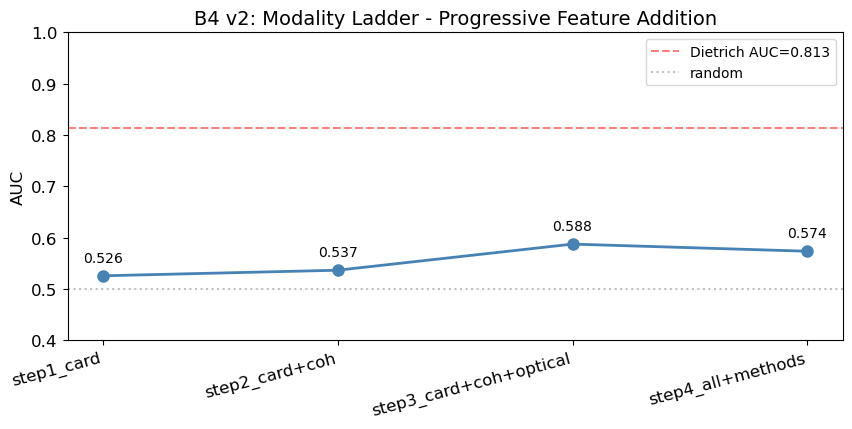

  Plot: cell_b4/modality_ladder_20260429_230339.png


In [9]:
# @title CELL B4: COMBINED UNSUPERVISED (modality ladder)
from scipy.stats import rankdata

print("=" * 70)
print("CELL B4: COMBINED UNSUPERVISED (modality ladder)")
print("=" * 70)

print(f"  Available score components ({len(ALL_SCORES)}): {sorted(ALL_SCORES.keys())}")

# --- categorize labels by modality ----------------------------------
card_labels = [k for k in ALL_SCORES if k.startswith('s1_v')]
coh_labels = [k for k in ALL_SCORES if k.startswith('s1_coh') or k.startswith('ccd_')]
optical_labels = [k for k in ALL_SCORES
                  if any(tok in k.lower() for tok in ('nbr', 'ndvi', 'bsi', 'ndwi',
                                                      's2_', 'comp_', 'b0', 'b0_', 'band'))]
method_labels = [k for k in ALL_SCORES
                 if k in ('pwtt_vv', 'pwtt_vh')
                 or k.startswith('logratio_')]

ladder_steps = []
if card_labels:
    ladder_steps.append(('step1_card', card_labels))
if coh_labels:
    ladder_steps.append(('step2_card+coh', card_labels + coh_labels))
if optical_labels:
    ladder_steps.append(('step3_card+coh+optical', card_labels + coh_labels + optical_labels))
if method_labels:
    ladder_steps.append(('step4_all+methods',
                          card_labels + coh_labels + optical_labels + method_labels))

all_labels = list(ALL_SCORES.keys())
if not ladder_steps or set(all_labels) != set(ladder_steps[-1][1]):
    ladder_steps.append(('step_full', all_labels))

print(f"\n  Modality ladder:")
for step_name, step_labels in ladder_steps:
    print(f"    {step_name}: {len(step_labels)} scores")

# --- evaluate ladder -----------------------------------------------
ref = df_points[['point_id', 'city', TARGET_COL]].drop_duplicates()
ref = ref[ref[TARGET_COL] >= 0]

print(f"\n  {'Step':<35s} {'N_scores':>9s} {'N_bldg':>8s} {'AUC':>7s}")
print(f"  {'-'*35} {'-'*9} {'-'*8} {'-'*7}")

ladder_results = {}

for step_name, step_labels in ladder_steps:
    merged = ref.copy()
    valid_labels = []
    seen_labels = set()
    for lbl in step_labels:
        if lbl in seen_labels or lbl not in ALL_SCORES:
            continue
        seen_labels.add(lbl)
        sdf = ALL_SCORES[lbl]
        score_col = [c for c in sdf.columns if c.startswith('score_')][0]
        merged = merged.merge(sdf[['point_id', 'city', score_col]],
                               on=['point_id', 'city'], how='inner')
        valid_labels.append(score_col)

    merged = merged.dropna(subset=valid_labels) if valid_labels else merged
    if len(merged) < 50 or merged[TARGET_COL].nunique() < 2 or not valid_labels:
        print(f"  {step_name:<35s} {len(valid_labels):>9d} {'SKIP':>8s}")
        continue
    y = merged[TARGET_COL].values
    for col in valid_labels:
        merged[f'{col}_rank'] = rankdata(merged[col]) / len(merged)
    rank_cols = [c for c in merged.columns if c.endswith('_rank')]
    merged['combined_score'] = merged[rank_cols].mean(axis=1)
    auc = roc_auc_score(y, merged['combined_score'].values)
    print(f"  {step_name:<35s} {len(valid_labels):>9d} {len(merged):>8d} {auc:>7.3f}")
    EXPERIMENT_LOG[f'B4_{step_name}'] = {'auc': auc, 'f1': np.nan,
                                          'n_features': len(valid_labels),
                                          'method': 'unsupervised_combined'}
    ladder_results[step_name] = {'auc': auc, 'n_scores': len(valid_labels),
                                   'n_bldg': len(merged)}
    registry.log_experiment(
        cell_id='cell_b4', experiment_name=f'B4_{step_name}',
        parquet_name='multiple_v3', tier_selection=_tiers,
        classifier_name='unsupervised_combined',
        feature_set_name=step_name, feature_cols=valid_labels,
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=merged['combined_score'].values,
        groups=merged['city'].values,
        note=f'Modality ladder: {step_name}, rank-averaged',
        tags=['unsupervised', 'combined', 'ladder', step_name],
    )
    save_oof_unsupervised(
        building_ids=merged['point_id'].values,
        cities=merged['city'].values,
        y_true=y, scores=merged['combined_score'].values,
        model_id=f'B4_{step_name}',
        variant_id=f'unsupervised_combined;step={step_name};n_scores={len(valid_labels)}',
    )

# --- OR-rule across full set ---------------------------------------
if ladder_steps:
    full_labels = ladder_steps[-1][1]
    merged_full = ref.copy()
    valid_full = []
    seen_full = set()
    for lbl in full_labels:
        if lbl in seen_full or lbl not in ALL_SCORES:
            continue
        seen_full.add(lbl)
        sdf = ALL_SCORES[lbl]
        score_col = [c for c in sdf.columns if c.startswith('score_')][0]
        merged_full = merged_full.merge(sdf[['point_id', 'city', score_col]],
                                          on=['point_id', 'city'], how='inner')
        valid_full.append(score_col)
    if valid_full:
        merged_full = merged_full.dropna(subset=valid_full)
        if len(merged_full) > 50 and merged_full[TARGET_COL].nunique() >= 2:
            y_full = merged_full[TARGET_COL].values
            or_flags = np.zeros(len(merged_full), dtype=bool)
            for col in valid_full:
                threshold = np.percentile(merged_full[col], 90)
                or_flags |= (merged_full[col] >= threshold).values
            auc_or = roc_auc_score(y_full, or_flags.astype(float))
            f1_or = f1_score(y_full, or_flags.astype(int))
            print(f"\n  OR-rule (any > 90th pct): AUC={auc_or:.3f}  F1={f1_or:.3f}")

# --- plot ----------------------------------------------------------
if ladder_results:
    fig, ax = plt.subplots(figsize=(10, 4))
    steps = list(ladder_results.keys())
    aucs = [ladder_results[s]['auc'] for s in steps]
    ax.plot(steps, aucs, 'o-', color='steelblue', linewidth=2, markersize=8)
    for i, (s, a) in enumerate(zip(steps, aucs)):
        ax.annotate(f'{a:.3f}', (i, a), textcoords='offset points', xytext=(0, 10), ha='center')
    ax.set_ylabel('AUC')
    ax.set_title('B4 v2: Modality Ladder - Progressive Feature Addition')
    ax.axhline(DIETRICH_PAPER['auc'], color='red', linestyle='--', alpha=0.5,
               label=f"Dietrich AUC={DIETRICH_PAPER['auc']}")
    ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5, label='random')
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    plt.xticks(rotation=15, ha='right')
    save_fig(fig, 'modality_ladder', 'cell_b4')

# CELL B5: UISEM ENSEMBLE BASELINE (F8 `fusion_composite_blockstats`)Ahmad 2024 soft-voting RF+GB+XGB+AdaBoost on all_multimodal (F8 fusion).Also reports individual sub-classifiers for comparison.GroupKFold by city. Loads F8 once, used also by B6 + B7.

In [10]:
# @title CELL B5: UISEM BASELINE (F8)
print("=" * 70)
print("CELL B5: UISEM ENSEMBLE BASELINE (F8 fusion_composite_blockstats)")
print("=" * 70)

df_f8 = load_v3('fusion_composite_blockstats')
f8_info = MANIFEST['parquets']['fusion_composite_blockstats']
feat_cols = [c for c in f8_info['feature_columns'] if c in df_f8.columns]
print(f"  F8 features: {len(feat_cols)} raw")

X, y, groups, building_ids, clean = prepare_Xy_from(df_f8, feat_cols)
if X is None:
    print("  SKIP: insufficient features after leakage drop")
else:
    print(f"  After leakage drop: {len(clean)} features, {len(y):,} points, {len(np.unique(groups))} cities")

    # UISEM with AdaBoost
    clf_ab = build_uisem(include_adaboost=True)
    res_ab = evaluate_groupkfold(clf_ab, X, y, groups, "B5_UISEM_all_features",
                                 building_ids=building_ids)
    save_oof_from_result(res_ab, 'B5_UISEM_all_features',
                         variant_id='uisem_ensemble;sub=RF+GB+XGB+AB;features=all_multimodal')
    log_result(res_ab, cell_id='cell_b5',
               parquet_name='bda_fusion_composite_blockstats_v3',
               feature_set_name='all_multimodal',
               classifier_name='UISEM_RF+GB+XGB+AB',
               feature_cols=clean, groups=groups,
               note='Ahmad 2024 UISEM: RF+GB+XGB+AdaBoost soft voting',
               tags=['uisem', 'ensemble', 'ahmad2024'])

    # sub-classifiers
    print(f"\n  Individual sub-classifiers:")
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                 random_state=RANDOM_STATE, n_jobs=-1,
                                 class_weight='balanced')
    res_rf = evaluate_groupkfold(rf, X, y, groups, "B5_sub_RF",
                                 building_ids=building_ids)
    save_oof_from_result(res_rf, 'B5_sub_RF',
                         variant_id='uisem_sub_classifier;classifier=RF;features=all_multimodal')
    log_result(res_rf, cell_id='cell_b5',
               parquet_name='bda_fusion_composite_blockstats_v3',
               feature_set_name='all_multimodal', classifier_name='RF-200',
               feature_cols=clean, groups=groups,
               note='UISEM sub-classifier: RF', tags=['uisem', 'sub_classifier'])

    gb = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                         num_leaves=31, random_state=RANDOM_STATE,
                         n_jobs=-1, verbose=-1)
    res_gb = evaluate_groupkfold(gb, X, y, groups, "B5_sub_GBM",
                                 building_ids=building_ids)
    save_oof_from_result(res_gb, 'B5_sub_GBM',
                         variant_id='uisem_sub_classifier;classifier=GBM;features=all_multimodal')
    log_result(res_gb, cell_id='cell_b5',
               parquet_name='bda_fusion_composite_blockstats_v3',
               feature_set_name='all_multimodal', classifier_name='GBM',
               feature_cols=clean, groups=groups,
               note='UISEM sub-classifier: GBM', tags=['uisem', 'sub_classifier'])

    if HAS_XGB:
        xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                             scale_pos_weight=5, eval_metric='logloss', verbosity=0)
        res_xgb = evaluate_groupkfold(xgb, X, y, groups, "B5_sub_XGB",
                                      building_ids=building_ids)
        save_oof_from_result(res_xgb, 'B5_sub_XGB',
                             variant_id='uisem_sub_classifier;classifier=XGBoost;features=all_multimodal')
        log_result(res_xgb, cell_id='cell_b5',
                   parquet_name='bda_fusion_composite_blockstats_v3',
                   feature_set_name='all_multimodal', classifier_name='XGBoost',
                   feature_cols=clean, groups=groups,
                   note='UISEM sub-classifier: XGBoost', tags=['uisem', 'sub_classifier'])

# keep df_f8 + X/y/groups in memory for B6 + B7
print(f"\n  Keeping df_f8 + X/y/groups in memory for B6 + B7")

CELL B5: UISEM ENSEMBLE BASELINE (F8 fusion_composite_blockstats)
  load_v3('fusion_composite_blockstats'): 62,043 rows, 415 cols, 19 cities
  F8 features: 185 raw
  After leakage drop: 179 features, 62,043 points, 19 cities
    B5_UISEM_all_features                        : AUC=0.655 (+/-0.031)  F1=0.034
    saved oof -> oof_B5_UISEM_all_features__20260429_230318_6835ef.parquet  TP=145 FN=7935 FP=262 TN=53701
  REG: B5_UISEM_all_features                         AUC=0.6546 F1=0.0342 n=62043 feat=179 cities=19 [NB09bV3_v1/cell_b5]

  Individual sub-classifiers:
    B5_sub_RF                                    : AUC=0.659 (+/-0.023)  F1=0.021
    saved oof -> oof_B5_sub_RF__20260429_230318_6835ef.parquet  TP=88 FN=7992 FP=169 TN=53794
  REG: B5_sub_RF                                     AUC=0.6591 F1=0.0211 n=62043 feat=179 cities=19 [NB09bV3_v1/cell_b5]
    B5_sub_GBM                                   : AUC=0.639 (+/-0.035)  F1=0.036
    saved oof -> oof_B5_sub_GBM__20260429_230318_6835

# CELL B6: ADABOOST ABLATIONReuses X/y/groups from B5. UISEM without AdaBoost + AdaBoost alone.

In [11]:
# @title CELL B6: ADABOOST ABLATION
print("=" * 70)
print("CELL B6: ADABOOST ABLATION")
print("=" * 70)

if 'X' in dir() and X is not None:
    clf_no_ab = build_uisem(include_adaboost=False)
    res_no_ab = evaluate_groupkfold(clf_no_ab, X, y, groups, "B6_UISEM_no_AdaBoost",
                                    building_ids=building_ids)
    save_oof_from_result(res_no_ab, 'B6_UISEM_no_AdaBoost',
                         variant_id='uisem_ensemble;sub=RF+GB+XGB;features=all_multimodal;ablation=no_adaboost')
    log_result(res_no_ab, cell_id='cell_b6',
               parquet_name='bda_fusion_composite_blockstats_v3',
               feature_set_name='all_multimodal',
               classifier_name='UISEM_RF+GB+XGB',
               feature_cols=clean, groups=groups,
               note='UISEM without AdaBoost (Ahmad 2024 ablation)',
               tags=['uisem', 'adaboost_ablation'])

    ab_only = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
    res_ab = evaluate_groupkfold(ab_only, X, y, groups, "B6_AdaBoost_alone",
                                 building_ids=building_ids)
    save_oof_from_result(res_ab, 'B6_AdaBoost_alone',
                         variant_id='uisem_sub_classifier;classifier=AdaBoost;features=all_multimodal')
    log_result(res_ab, cell_id='cell_b6',
               parquet_name='bda_fusion_composite_blockstats_v3',
               feature_set_name='all_multimodal', classifier_name='AdaBoost',
               feature_cols=clean, groups=groups,
               note='AdaBoost alone for ablation comparison',
               tags=['uisem', 'adaboost_ablation'])

    with_ab = EXPERIMENT_LOG.get('B5_UISEM_all_features', {}).get('auc', np.nan)
    without_ab = EXPERIMENT_LOG.get('B6_UISEM_no_AdaBoost', {}).get('auc', np.nan)
    if not np.isnan(with_ab) and not np.isnan(without_ab):
        delta = with_ab - without_ab
        impact = 'Negligible' if abs(delta) < 0.005 else 'Positive' if delta > 0 else 'Negative'
        print(f"\n  AdaBoost impact: {delta:+.3f} AUC ({with_ab:.3f} with vs {without_ab:.3f} without) [{impact}]")
else:
    print("  SKIP: B5 did not produce X/y/groups")

CELL B6: ADABOOST ABLATION
    B6_UISEM_no_AdaBoost                         : AUC=0.646 (+/-0.032)  F1=0.045
    saved oof -> oof_B6_UISEM_no_AdaBoost__20260429_230318_6835ef.parquet  TP=196 FN=7884 FP=367 TN=53596
  REG: B6_UISEM_no_AdaBoost                          AUC=0.6459 F1=0.0454 n=62043 feat=179 cities=19 [NB09bV3_v1/cell_b6]
    B6_AdaBoost_alone                            : AUC=0.657 (+/-0.039)  F1=0.001
    saved oof -> oof_B6_AdaBoost_alone__20260429_230318_6835ef.parquet  TP=6 FN=8074 FP=43 TN=53920
  REG: B6_AdaBoost_alone                             AUC=0.6575 F1=0.0015 n=62043 feat=179 cities=19 [NB09bV3_v1/cell_b6]

  AdaBoost impact: +0.009 AUC (0.655 with vs 0.646 without) [Positive]


# CELL B7: UISEM SENSOR ABLATIONDerives sensor-group subsets from F8 columns and runs UISEM (no AdaBoost)on each. Groups: card_only, coh_only, ms_only, delta_only, combos, all.

In [12]:
# @title CELL B7: UISEM SENSOR ABLATION
print("=" * 70)
print("CELL B7: UISEM SENSOR ABLATION (F8)")
print("=" * 70)

if 'df_f8' not in dir():
    print("  SKIP: df_f8 not in memory (re-run B5 first)")
else:
    f8_info = MANIFEST['parquets']['fusion_composite_blockstats']
    all_feats = [c for c in f8_info['feature_columns'] if c in df_f8.columns]
    all_feats = drop_leakage(all_feats)

    # classify columns into sensor groups
    card_feats = [c for c in all_feats
                   if c.startswith('s1__') and not c.startswith('s1__coh')
                   and 'delta' not in c.lower()]
    coh_feats = [c for c in all_feats if 'coh' in c.lower()]
    ms_feats = [c for c in all_feats
                 if c.startswith('s2__') or c.startswith('comp_')
                 or c.startswith('lu_') or c.startswith('landuse')
                 or c.startswith('idx_') or c.startswith('spectral')
                 or c.startswith('cd_') or c.startswith('fire')
                 or c.startswith('vis')]
    delta_feats = [c for c in all_feats if '__delta__' in c or c.startswith('delta_')]

    ABLATION_GROUPS_V2 = {
        'card_only': card_feats,
        'coh_only': coh_feats,
        'ms_only': ms_feats,
        'delta_only': delta_feats,
        'card+coh': list(dict.fromkeys(card_feats + coh_feats)),
        'card+ms': list(dict.fromkeys(card_feats + ms_feats)),
        'coh+ms': list(dict.fromkeys(coh_feats + ms_feats)),
        'card+coh+delta': list(dict.fromkeys(card_feats + coh_feats + delta_feats)),
        'all_multimodal': all_feats,
    }

    print(f"  Ablation group sizes:")
    for gname, feats in ABLATION_GROUPS_V2.items():
        print(f"    {gname:<20s}: {len(feats)} features")

    for gname, feats in sorted(ABLATION_GROUPS_V2.items(), key=lambda x: len(x[1])):
        X_g, y_g, groups_g, building_ids_g, clean_g = prepare_Xy_from(df_f8, feats)
        if X_g is None:
            print(f"    {gname:<20s}: SKIP (insufficient features)")
            continue
        clf = build_uisem(include_adaboost=False)
        res = evaluate_groupkfold(clf, X_g, y_g, groups_g, f"B7_UISEM_{gname}",
                                  building_ids=building_ids_g)
        save_oof_from_result(res, f'B7_UISEM_{gname}',
                             variant_id=f'uisem_sensor_ablation;sub=RF+GB+XGB;sensor_group={gname}')
        log_result(res, cell_id='cell_b7',
                   parquet_name='bda_fusion_composite_blockstats_v3',
                   feature_set_name=gname, classifier_name='UISEM_RF+GB+XGB',
                   feature_cols=clean_g, groups=groups_g,
                   note=f'UISEM sensor ablation: {gname}',
                   tags=['uisem', 'sensor_ablation', gname])

    # free F8 after B7 is done
    del df_f8
    gc.collect()
    print(f"\n  Released df_f8")

CELL B7: UISEM SENSOR ABLATION (F8)
  Ablation group sizes:
    card_only           : 88 features
    coh_only            : 12 features
    ms_only             : 79 features
    delta_only          : 0 features
    card+coh            : 100 features
    card+ms             : 167 features
    coh+ms              : 91 features
    card+coh+delta      : 100 features
    all_multimodal      : 185 features
    delta_only          : SKIP (insufficient features)
    B7_UISEM_coh_only                            : AUC=0.481 (+/-0.030)  F1=0.008
    saved oof -> oof_B7_UISEM_coh_only__20260429_230318_6835ef.parquet  TP=35 FN=8045 FP=158 TN=53805
  REG: B7_UISEM_coh_only                             AUC=0.4807 F1=0.0085 n=62043 feat=12 cities=19 [NB09bV3_v1/cell_b7]
    B7_UISEM_ms_only                             : AUC=0.647 (+/-0.038)  F1=0.076
    saved oof -> oof_B7_UISEM_ms_only__20260429_230318_6835ef.parquet  TP=340 FN=7740 FP=567 TN=53396
  REG: B7_UISEM_ms_only                            

# CELL B8: COMPARISON TABLEAll NB09b methods + paper references. No parquet load.

In [13]:
# @title CELL B8: COMPARISON TABLE
print("=" * 70)
print("CELL B8: COMPARISON TABLE")
print("=" * 70)

print(f"\n  {'Method':<50s} {'AUC':>7s} {'F1':>7s} {'Type':>18s} {'N_feat':>7s}")
print(f"  {'-'*50} {'-'*7} {'-'*7} {'-'*18} {'-'*7}")

print(f"  {'Dietrich 2025 (paper)':<50s} {DIETRICH_PAPER['auc']:>7.3f} {DIETRICH_PAPER['f1']:>7.3f} {'paper':>18s} {'28':>7s}")
print(f"  {'Ballinger 2024 PWTT (paper)':<50s} {BALLINGER_PAPER['auc']:>7.3f} {'--':>7s} {'paper':>18s} {'1':>7s}")

for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    method = res.get('method', 'supervised')
    auc = res.get('auc', np.nan)
    f1 = res.get('f1', np.nan)
    nf = res.get('n_features', '?')
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else "--"
    f1_str = f"{f1:.3f}" if not np.isnan(f1) else "--"
    print(f"  {key:<50s} {auc_str:>7s} {f1_str:>7s} {method:>18s} {str(nf):>7s}")

unsup = {k: v for k, v in EXPERIMENT_LOG.items() if v.get('method', '').startswith('unsup')}
sup = {k: v for k, v in EXPERIMENT_LOG.items() if not v.get('method', '').startswith('unsup')}
if unsup:
    best_unsup = max(unsup.items(), key=lambda x: x[1].get('auc', 0))
    print(f"\n  Best unsupervised: {best_unsup[0]} (AUC={best_unsup[1]['auc']:.3f})")
if sup:
    best_sup = max(sup.items(), key=lambda x: x[1].get('auc', 0))
    print(f"  Best supervised:   {best_sup[0]} (AUC={best_sup[1]['auc']:.3f})")

# save comparison table
comp_rows = [
    {'method': 'Dietrich 2025 (paper)', 'auc': DIETRICH_PAPER['auc'], 'f1': DIETRICH_PAPER['f1'],
     'type': 'paper', 'n_features': 28},
    {'method': 'Ballinger 2024 PWTT (paper)', 'auc': BALLINGER_PAPER['auc'], 'f1': np.nan,
     'type': 'paper', 'n_features': 1},
]
for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    comp_rows.append({
        'method': key, 'auc': res.get('auc', np.nan), 'f1': res.get('f1', np.nan),
        'type': res.get('method', 'supervised'), 'n_features': res.get('n_features', 0),
    })
comp_df = pd.DataFrame(comp_rows)
save_result(comp_df, 'comparison_table', 'cell_b8')

registry.log_reference('Dietrich_2025', auc=DIETRICH_PAPER['auc'], f1=DIETRICH_PAPER['f1'],
                        precision=DIETRICH_PAPER['precision'], recall=DIETRICH_PAPER['recall'],
                        n_features=28, paper='Dietrich et al. 2025',
                        note='GEE RF, geographic split')
registry.log_reference('Ballinger_2024_PWTT', auc=BALLINGER_PAPER['auc'], n_features=1,
                        paper='Ballinger 2024', note='unsupervised PWTT on Ukraine')

# bar chart
fig, ax = plt.subplots(figsize=(10, max(4, len(comp_df) * 0.30)))
colors = ['red' if t == 'paper' else 'orange' if 'unsup' in str(t) else 'steelblue'
          for t in comp_df['type']]
ax.barh(comp_df['method'], comp_df['auc'].fillna(0), color=colors, edgecolor='black')
ax.set_xlabel('AUC')
ax.set_xlim(0.4, 1.0)
ax.set_title('NB09bV3 v1: All Methods Comparison')
ax.axvline(DIETRICH_PAPER['auc'], color='red', linestyle='--', alpha=0.5,
           label=f"Dietrich AUC={DIETRICH_PAPER['auc']}")
ax.legend()
save_fig(fig, 'comparison_bar', 'cell_b8')

# final summary json for NB13
summary = {
    'notebook': 'NB09bV3_v1',
    'n_experiments': len(EXPERIMENT_LOG),
    'best_unsupervised': best_unsup[0] if unsup else None,
    'best_supervised': best_sup[0] if sup else None,
    'experiments': {k: {kk: vv for kk, vv in v.items()
                         if kk not in ('y_true', 'y_proba', 'groups', 'fold_aucs')}
                     for k, v in EXPERIMENT_LOG.items()},
}
save_result(summary, 'nb09b_summary', 'cell_b8', fmt='json')

# ---- OOF predictions inventory (for NB12 overlap analysis) ----
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09b_oof_inventory', 'cell_b8')
    print(f"  Total OOF parquets: {len(oof_files)}")
else:
    print("  No OOF parquets saved")

try:
    registry.save()
except Exception as e:
    print(f"  registry.save() error: {e}")

CELL B8: COMPARISON TABLE

  Method                                                 AUC      F1               Type  N_feat
  -------------------------------------------------- ------- ------- ------------------ -------
  Dietrich 2025 (paper)                                0.813   0.749              paper      28
  Ballinger 2024 PWTT (paper)                          0.870      --              paper       1
  B0_single_s1_coh_drop_count                          0.504      --       unsupervised       1
  B0_single_s1_coh_max_drop                            0.515      --       unsupervised       1
  B0_single_s1_coh_running_min                         0.524      --       unsupervised       1
  B0_single_s1_vh_mean                                 0.523      --       unsupervised       1
  B0_single_s1_vv_mean                                 0.518      --       unsupervised       1
  B1_PWTT_VH_exact                                     0.531      --       unsupervised       1
  B1_PWTT_VV+

TypeError: ResultRegistry.log_experiment() got an unexpected keyword argument 'n_features'